# Environmental Impact on Frog Presence

This project analyzes the correlation between the presence and absence of frogs based on various environmental parameters.

Because our target variable (frog presence) is binary—meaning the frogs are either there or they aren't—we will use the **Point-Biserial Correlation**. This statistical method is specifically designed to measure the strength and direction of the relationship between a continuous variable (like temperature or distance) and a dichotomous/binary variable.

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import t, shapiro, norm

In [2]:
#Reading the CSV file
#df = pd.read_csv("../Data/frogs.csv", index_col=0)
df = pd.read_csv("data/frogs.csv", index_col=0)

In [3]:
#Show the headers
print(df.head())

   pres.abs  northing  easting  altitude  distance  NoOfPools  NoOfSites  \
2         1       115     1047      1500       500        232          3   
3         1       110     1042      1520       250         66          5   
4         1       112     1040      1540       250         32          5   
5         1       109     1033      1590       250          9          5   
6         1       109     1032      1590       250         67          5   

       avrain   meanmin    meanmax  
2  155.000000  3.566667  14.000000  
3  157.666667  3.466667  13.800000  
4  159.666667  3.400000  13.600000  
5  165.000000  3.200000  13.166667  
6  165.000000  3.200000  13.166667  


In [4]:
#Adding the temperature columns for analysis
df["temp_diff"] = df["meanmax"] - df["meanmin"]
df["temp_mid"] = (df["meanmax"] + df["meanmin"])/2

# Trying the Point-Biserial Correlation Test
## Doesn't work as the data isn't normal

In [5]:
#The function to calculate the Point-Biserial Correlation and test
def PointBiserial(binary_data, continuous_data):
    present = continuous_data[binary_data==1]
    absent = continuous_data[binary_data==0]
    M1 = present.mean()
    M0 = absent.mean()
    S = continuous_data.std()
    N = len(binary_data)
    N1 = len(binary_data[binary_data==1])
    N0 = len(binary_data[binary_data==0])
    CorrCoef = (M1 - M0)/S * (np.sqrt(N1*N0/(N*(N-1))))
    #Check the normality of the data using Shapiro-Wilk test with p=0.05
    if shapiro(present).pvalue < 0.05 or shapiro(absent).pvalue < 0.05:
        print("Warning: Data is not normally distributed. Test invalid.")
        return CorrCoef, None
    #H0: CorrCoef = 0
    tStat = CorrCoef*np.sqrt((N-2)/(1-CorrCoef**2))
    degrees_of_freedom = N - 2
    p_value = 2 * t.sf(np.abs(tStat), degrees_of_freedom)
    return CorrCoef, p_value

In [6]:
#Calculating the Point-Biserial Correlation for each column
columns_to_remove = ["pres.abs", "northing", "easting", "meanmin", "meanmax"]
Columns = df.columns.difference(columns_to_remove)

Outputs = []
for col in Columns:
    corr, p_val = PointBiserial(df["pres.abs"], df[col])
    if p_val is None:
        sig_label = "Invalid (Not Normal)"
    elif p_val <= 0.05:
        sig_label = "Significant"
    else:
        sig_label = "Not Significant"
    Outputs.append([col, corr, p_val, sig_label])
pd.DataFrame(Outputs, columns=['Feature', 'Correlation', 'P-Value', 'Significance'])

,Feature,Correlation,P-Value,Significance
0,NoOfPools,0.175624,None,Invalid (Not Normal)
1,NoOfSites,0.160710,None,Invalid (Not Normal)
2,altitude,-0.238410,None,Invalid (Not Normal)
3,avrain,-0.013582,None,Invalid (Not Normal)
4,distance,-0.321748,None,Invalid (Not Normal)
5,temp_diff,0.050456,None,Invalid (Not Normal)
6,temp_mid,0.270114,None,Invalid (Not Normal)


# Visualising the Histograms to understand the Distributions

In [7]:
#The libraries for plotting
import seaborn as sns
import matplotlib.pyplot as plt

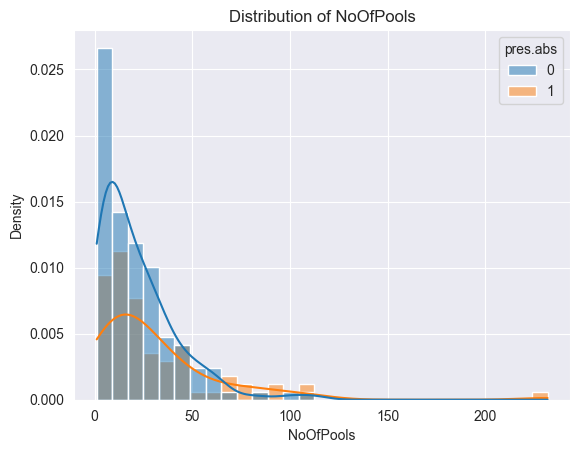

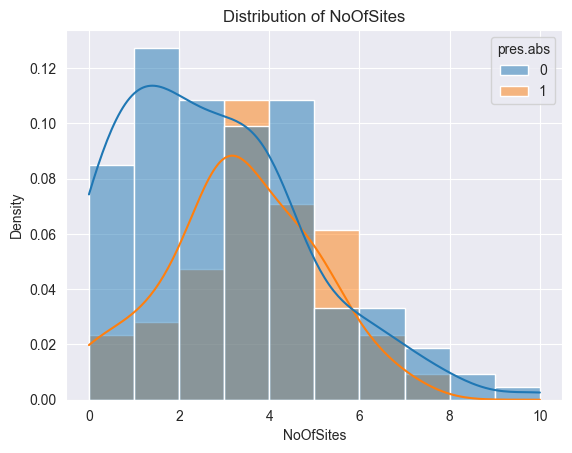

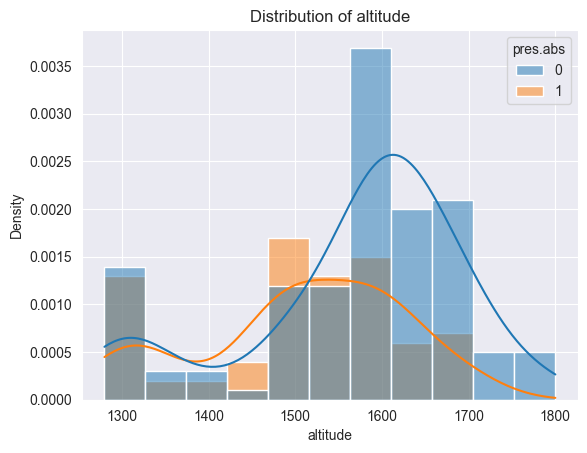

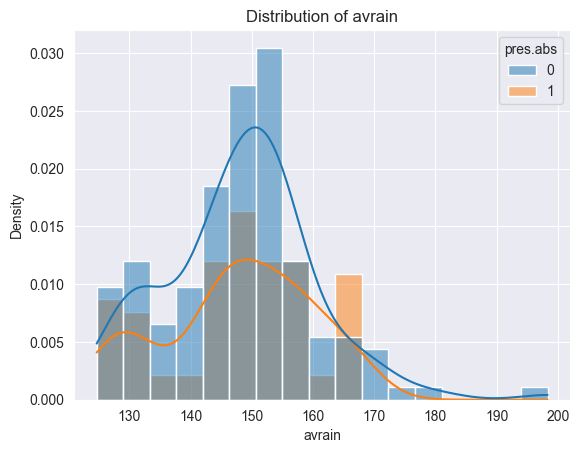

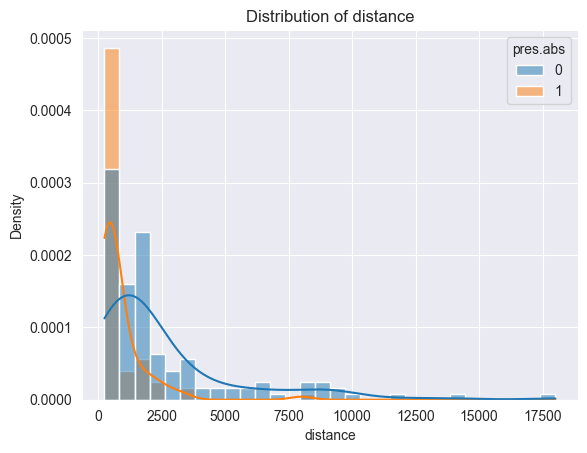

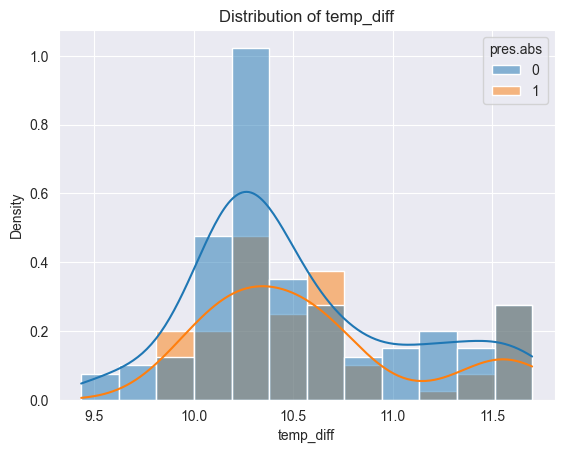

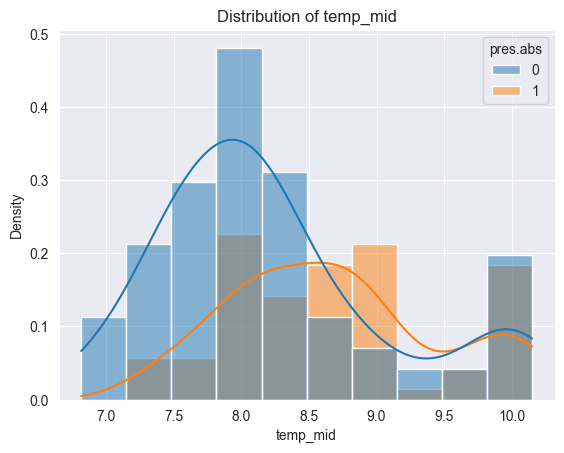

In [8]:
#Plotting the histograms
for col in Columns:
    # Plot the histogram for the current column
    sns.histplot(data=df, x=col, hue="pres.abs", kde=True, stat="density")

    # Add a title so you know which chart you are looking at
    plt.title(f"Distribution of {col}")

    # Render the chart and start a fresh canvas for the next loop
    plt.show()

# Mann-Whitney U-test

In [11]:
#Defining the U-test function
def Utest(binary_data, continuous_data):
    Ranking = continuous_data.rank()
    R1 = Ranking[binary_data==1].sum()
    R0 = Ranking[binary_data==0].sum()
    N1 = len(Ranking[binary_data==1])
    N0 = len(Ranking[binary_data==0])
    U1 = N1*N0+N1*(N1+1)/2 - R1
    U0 = N0*N1+N0*(N0+1)/2 - R0
    U = min(U1, U0)
    #We will use the z-test for the p-value
    Umean = (N1*N0)/2
    Usd = np.sqrt(N1*N0*(N1+N0+1)/12)
    Z = (U-Umean)/Usd
    p_value = 2 * norm.sf(np.abs(Z))
    return U, p_value

In [15]:
#Calculating the Mann-Whitney U-test for each column
columns_to_remove = ["pres.abs", "northing", "easting", "meanmin", "meanmax"]
Columns = df.columns.difference(columns_to_remove)
Outputs = []
for col in Columns:
    u, p_val = Utest(df["pres.abs"], df[col])
    if p_val <= 0.05:
        sig_label = "Significant"
    else:
        sig_label = "Not Significant"
    Outputs.append([col, u, p_val, sig_label])
Final = pd.DataFrame(Outputs, columns=['Feature', 'Value of U', 'P-Value', 'Significance'])
print(Final)
Final.to_csv("data/u_test_results.csv", index=False)

     Feature  Value of U       P-Value     Significance
0  NoOfPools      4277.5  2.382034e-02      Significant
1  NoOfSites      4025.0  4.445314e-03      Significant
2   altitude      3464.0  3.416777e-05      Significant
3     avrain      5203.5  9.078273e-01  Not Significant
4   distance      2316.0  1.031463e-11      Significant
5  temp_diff      4910.0  4.263781e-01  Not Significant
6   temp_mid      3288.0  5.331801e-06      Significant
